### Klaszterezés (Clustering)

A **klaszterezés** egy **felügyelt tanulás nélküli (unsupervised)** gépi tanulási technika, amelynek célja az adatok **csoportosítása** hasonlóság alapján.

Mi a klaszterezés?

- A klaszterezés olyan módszer, amely az adatpontokat **automatikusan csoportokba rendezi** úgy, hogy:
  - **Egy klaszteren belül** az elemek **minél hasonlóbbak** legyenek egymáshoz.
  - **Klaszterek között** az elemek **minél különbözőbbek** legyenek.

Példák:

- Vásárlók szegmentálása viselkedés alapján.
- Dokumentumok csoportosítása tartalom szerint.
- Szenszoradatok klaszterezése működési állapot szerint.
- Képek csoportosítása vizuális hasonlóság alapján.

Miért fontos?

A klaszterezés **strukturáltabbá teszi az adathalmazt**, segít:
- minták felismerésében,
- anomáliák megtalálásában,
- felhasználók célzottabb kiszolgálásában.

A következő lépésekben különböző klaszterezési algoritmusokat és vizualizációkat mutatunk be egyszerű adatokon.

### Manuális távolság-alapú klaszterezés

Cél: 2 klasztert hozzunk létre kézzel, Euklidészi távolság alapján.

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Egyszerű pontok létrehozása
X = np.array([
    [1, 2],
    [1, 4],
    [1, 0],
    [10, 2],
    [10, 4],
    [10, 0]
])

# 2. Kezdeti klaszterközéppontok manuálisan
centroids = np.array([
    [1, 2],    # klaszter 0
    [10, 2]    # klaszter 1
])

# 3. Euklidészi távolság számítása és hozzárendelés
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

labels = assign_clusters(X, centroids)

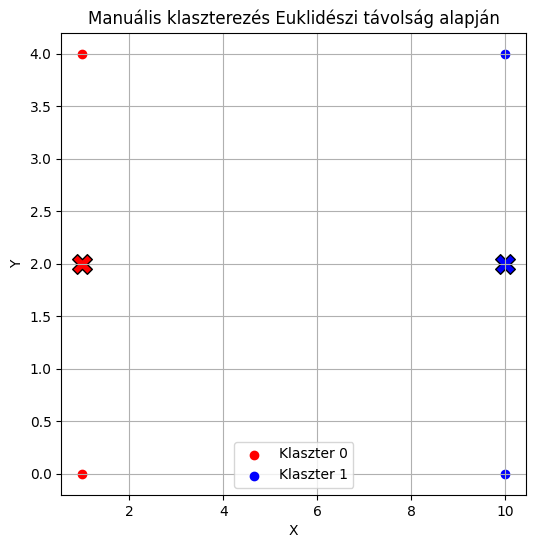

In [5]:
# 4. Vizualizáció
colors = ['red', 'blue']
plt.figure(figsize=(6, 6))
for i in range(len(centroids)):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f"Klaszter {i}")
    plt.scatter(centroids[i, 0], centroids[i, 1], color=colors[i], marker='X', s=200, edgecolor='black')

plt.title("Manuális klaszterezés Euklidészi távolság alapján")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.show()

### Hogyan működik?
1. Kiválasztunk két "középpontot" manuálisan.
2. Minden pont esetén kiszámoljuk a **távolságot** mindkét középponthoz.
3. Minden pontot ahhoz a középponthoz rendelünk, amelyikhez közelebb van.

Ez egy egyszerű példája a **Közelség-alapú klaszterezésnek**, amely a `KMeans` algoritmus alapja is.



### Manuális klaszterezés véletlenszerűen generált pontokon

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Random pontok generálása két központ köré
np.random.seed(42)

# 50 pont az (1, 2) körül
cluster_0 = np.random.normal(loc=[1, 2], scale=0.7, size=(50, 2))

# 50 pont a (10, 2) körül
cluster_1 = np.random.normal(loc=[10, 2], scale=0.7, size=(50, 2))

# Összefűzés
X = np.vstack((cluster_0, cluster_1))

# 2. Klaszterközéppontok (manuálisan megadva)
centroids = np.array([
    [1, 2],    # klaszter 0
    [10, 2]    # klaszter 1
])

# 3. Euklidészi távolság alapú hozzárendelés
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

labels = assign_clusters(X, centroids)

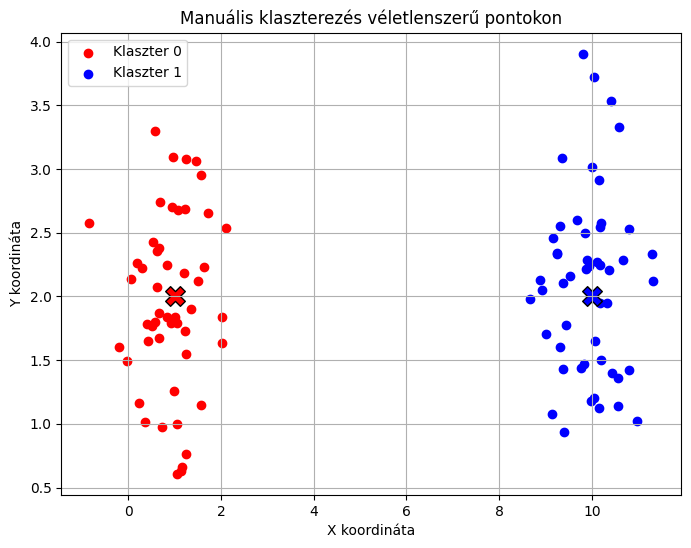

In [13]:
# 4. Vizualizáció
colors = ['red', 'blue']
plt.figure(figsize=(8, 6))
for i in range(len(centroids)):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f"Klaszter {i}")
    plt.scatter(centroids[i, 0], centroids[i, 1], color=colors[i], marker='X', s=200, edgecolor='black')

plt.title("Manuális klaszterezés véletlenszerű pontokon")
plt.xlabel("X koordináta")
plt.ylabel("Y koordináta")
plt.grid(True)
plt.legend()
plt.show()

### Véletlenszerű pontokon végzett manuális klaszterezés

Ebben a példában 100 pontot generáltunk:
- 50 pont az (1, 2) középpont körül (piros)
- 50 pont a (10, 2) középpont körül (kék)

A pontokat az Euklidészi távolság alapján rendeltük hozzá a legközelebbi klaszterközépponthoz.

Ez a példa megmutatja, hogy már egy egyszerű szabályalapú eljárással is **viszonylag jól elkülöníthető csoportokat** tudunk kialakítani.


### KMeans algoritmus

A KMeans algoritmus,a leggyakrabban használt klaszterezési módszer. Alapja az, amit eddig kézzel csináltunk: távolság számítás és hozzárendelés, de már automatizáltan és többszöri középpontfrissítéssel.

Lépések, amit a KMeans algoritmus végez:
- K klaszterközéppont véletlenszerű inicializálása.
- Minden pont hozzárendelése a legközelebbi középponthoz (távolság alapján).
- A klaszterek új középpontjainak kiszámítása (átlagolással).
- Ismétlés, amíg a klaszterek nem változnak -> konvergencia.

  File "C:\Users\koros\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\koros\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\koros\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\koros\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


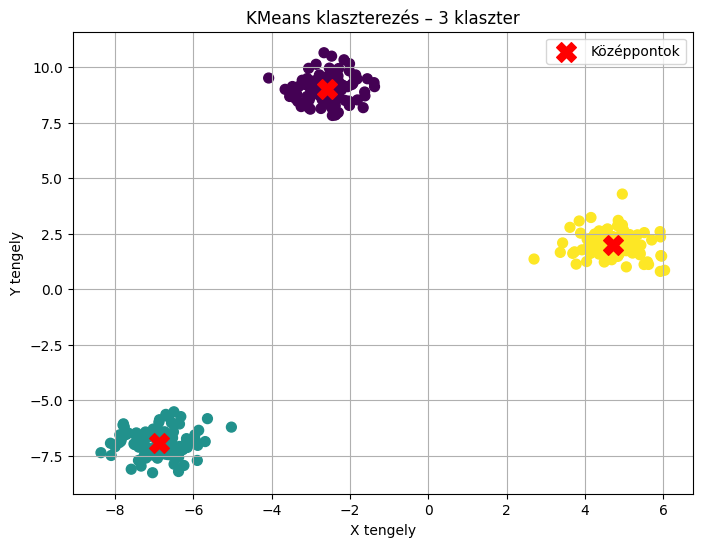

In [17]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Szintetikus adat generálása
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

# 2. KMeans modell illesztése
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)

# 3. Klaszter címkék és középpontok
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 4. Eredmény vizualizálása
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Középpontok')
plt.title("KMeans klaszterezés – 3 klaszter")
plt.xlabel("X tengely")
plt.ylabel("Y tengely")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
X.shape

(300, 2)

Mit látunk?

- A Kmeans klaszterezés jól működött és képes volt megtalálni a szintetikus adatok középpontját
- bár csak 2 feature-t generáltunk (2D tér), a Kmeans jól működik többdimenziós térben is.



Most használjuk a KMeans algoritmust az Iris dataset-en, hogy bemutassuk a valódi adatokon történő klaszterezést.

Lépések:
- Adat betöltése: Az Iris dataset betöltése és előkészítése.
- KMeans alkalmazása: Az algoritmus illesztése és klaszterek létrehozása.
- Eredmények vizualizálása: Klaszterek ábrázolása és az eredmények elemzése.
- K optimalizálása: Az Elbow módszer segítségével meghatározzuk a legjobb K értéket (optimális klaszterszám).

In [23]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Adat betöltése
iris = load_iris()
X = iris.data
y = iris.target  # valódi címkék

# 2. KMeans klaszterezés
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_


### FIGYELEM!

- Nincs train/test halmaz vágás, hiszen nincs is igazi tanulási folyamat

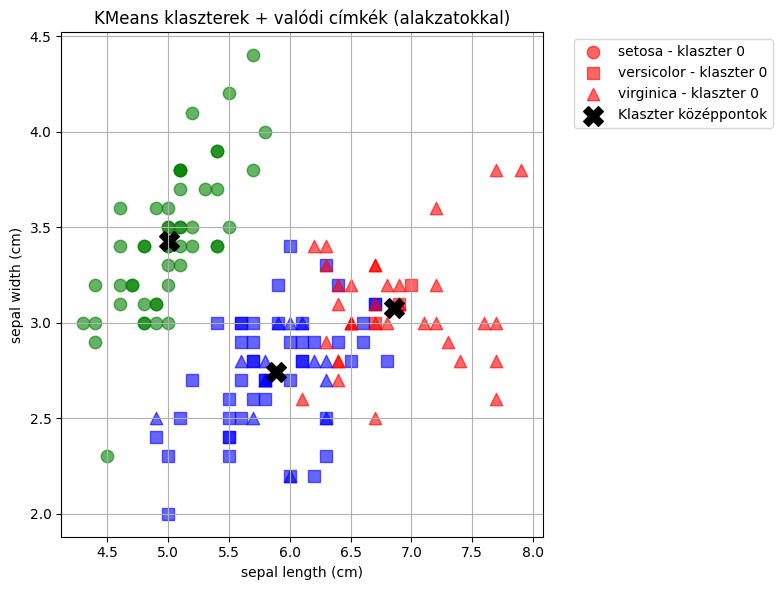

In [26]:
# 3. Címkék és alakzat hozzárendelés
markers = ['o', 's', '^']
label_names = iris.target_names
colors = ['red', 'green', 'blue']

# 4. Ábra
plt.figure(figsize=(8, 6))

for i in range(3):  # 3 valódi faj
    for j in range(3):  # 3 klaszter
        mask = (y == i) & (labels == j)
        plt.scatter(
            X[mask, 0], X[mask, 1],
            marker=markers[i],
            color=colors[j],
            s=80,
            label=f"{label_names[i]} - klaszter {j}" if j == 0 else "",
            alpha=0.6
        )

# Klaszterközéppontok
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c='black', marker='X', s=200, label='Klaszter középpontok'
)

plt.title("KMeans klaszterek + valódi címkék (alakzatokkal)")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### Magyarázat:
- KMeans illesztése: Az algoritmus 3 klasztert fog találni, mert az Iris dataset három különböző fajt tartalmaz.
- Bár esetünkben tudjuk, hogy valójában 3 klaszterünk van, ez a "varázsszám" meghatározása nem mindig ilyen egyértelmű.

In [29]:
X.shape

(150, 4)

In [31]:
pd.Series(labels).value_counts()

2    61
1    50
0    39
Name: count, dtype: int64

### K Optimalizálása (Elbow módszer)
Most nézzük meg, hogy miért 3 klasztert választottunk. Használjuk az Elbow módszert, hogy meghatározzuk az optimális K értéket.

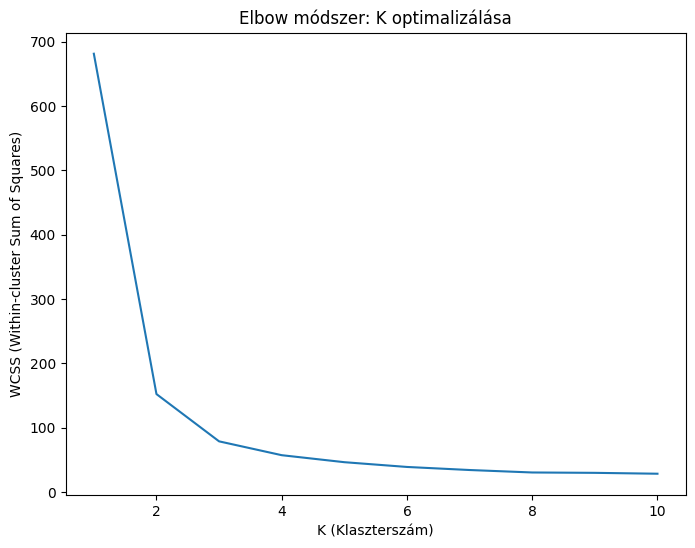

In [34]:
# 4. K Optimalizálása – Elbow módszer
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # Különbség a klaszterekhez rendelt pontok távolságainak négyzetösszegéhez

# Ábra: Elbow módszer
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss)
plt.title("Elbow módszer: K optimalizálása")
plt.xlabel("K (Klaszterszám)")
plt.ylabel("WCSS (Within-cluster Sum of Squares)")
plt.show()


### Elbow módszer magyarázata:
- WCSS (Within-cluster Sum of Squares): A klaszterekhez rendelt pontok távolságainak négyzetösszege. Minél kisebb, annál jobb a klaszterek összesűrűsödése.
- Az Elbow módszer azt keresi, hogy mikor csökken a leglassabban a WCSS, vagyis mikor válik a legkevesebb új információval az új klaszterek hozzáadása.

### Több kalszter csomópont?

Nyilván az IRIS dataset-en könnyű volt megállapitani, hogy 3 az optimális csomópont, hiszen egyrészről TUDJUK, hogy 3 tipus van, és az ELBOW is ezt mutatta. Tegyünk azonban egy próbát. Mi történne, ha több csomópontot csinálnánk?

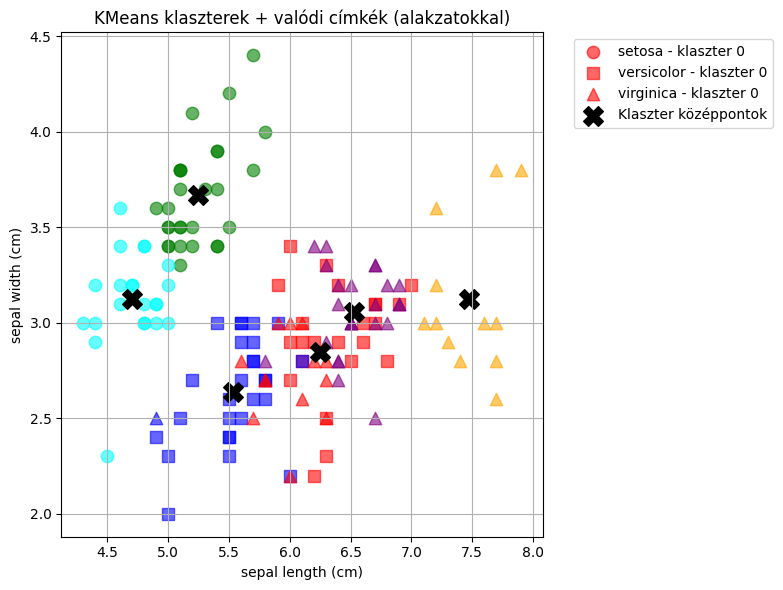

In [38]:
# 1. KMeans klaszterezés
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# 2. Címkék és alakzat hozzárendelés
markers = ['o', 's', '^']
label_names = iris.target_names
colors = ['red', 'green', 'blue', 'orange', 'purple', 'cyan']

# 4. Ábra
plt.figure(figsize=(8, 6))

for i in range(3):  # 3 valódi faj
    for j in range(6):  # 3 klaszter
        mask = (y == i) & (labels == j)
        plt.scatter(
            X[mask, 0], X[mask, 1],
            marker=markers[i],
            color=colors[j],
            s=80,
            label=f"{label_names[i]} - klaszter {j}" if j == 0 else "",
            alpha=0.6
        )

# Klaszterközéppontok
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c='black', marker='X', s=200, label='Klaszter középpontok'
)

plt.title("KMeans klaszterek + valódi címkék (alakzatokkal)")
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
pd.Series(labels).value_counts()

0    36
1    28
2    28
4    24
5    22
3    12
Name: count, dtype: int64

**Magyarázat:**

A klaszeterezének még igy is van értelme. Viszont az látható, hogy felesleges középontok alakultak ki. Nyilván ettől nem rosz a megoldásunk, csupán több klaszter középpontunk lett.

### Hierarchikus klaszterezés

A hierarchikus klaszterezést, a klaszterezési algoritmusok egy másik fontos típusa!

Alapgondolat:

- Ahelyett, hogy előre megmondanánk, hány klasztert szeretnénk (K), a hierarchikus klaszterezés fokozatosan épít vagy bont klasztereket.

Két típusa van:
- Agglomeratív (bottom-up): minden pont önálló klaszterként indul, majd fokozatosan összeolvadnak.
- Divizív (top-down): minden adat egy nagy klaszterben van, és fokozatosan osztódik.

### Agglomeratív klaszterezés

### Miért használunk dimmenzió csökkentést? (PCA)
- Gyakran többdimenziós adattal dolgozunk melynek vizulációja nehézkes
- Érdemen csak 2-2 paraméter alapján is kirajzolni a clustereket, mely akár plusz információt is nyújthat
- amennyiben nem akarunk bajlódni a "vajon melyik 2 paraméter legyen az X/Y tengelyen"-el, akkor egy lehetőség, hogy a PCA, T-NSE, stb. segitségével a tübbdimenziós teret 2 dimenzióra zsugoritsuk.

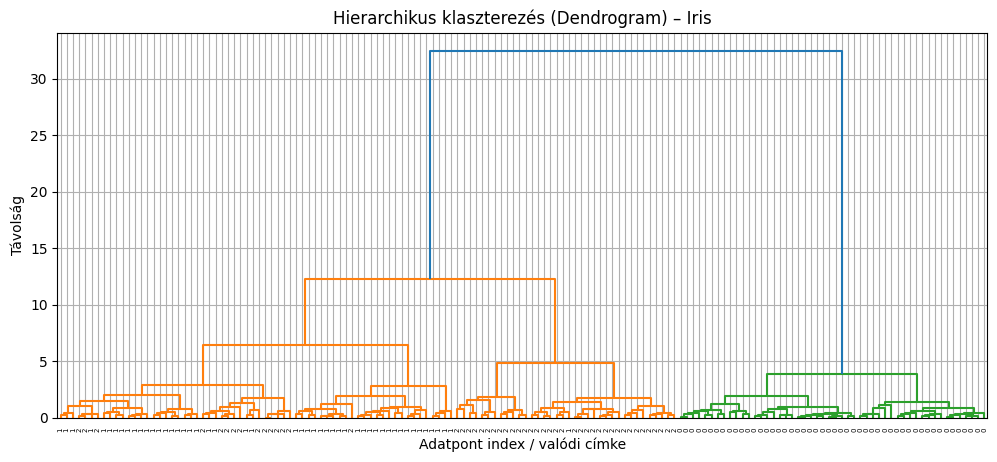

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

# 1. Adatok betöltése
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# 2. Dendrogram – hogyan épülnek fel a klaszterek?
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           labels=y)
plt.title("Hierarchikus klaszterezés (Dendrogram) – Iris")
plt.xlabel("Adatpont index / valódi címke")
plt.ylabel("Távolság")
plt.grid(True)
plt.show()


**Fontos:** A dendrogram() függvény alapértelmezetten nem a címkék (labels=y) alapján színezi az ágakat, hanem a klaszterezés szerkezetéből határozza meg a színeket.

### Mi az a dendrogram?
A dendrogram egy fa diagram, amely megmutatja, hogyan épülnek fel a klaszterek az egyes lépésekben.

Ha vízszintesen elvágjuk a fát egy adott szintnél, akkor megkapjuk az ott létrejött klasztereket.

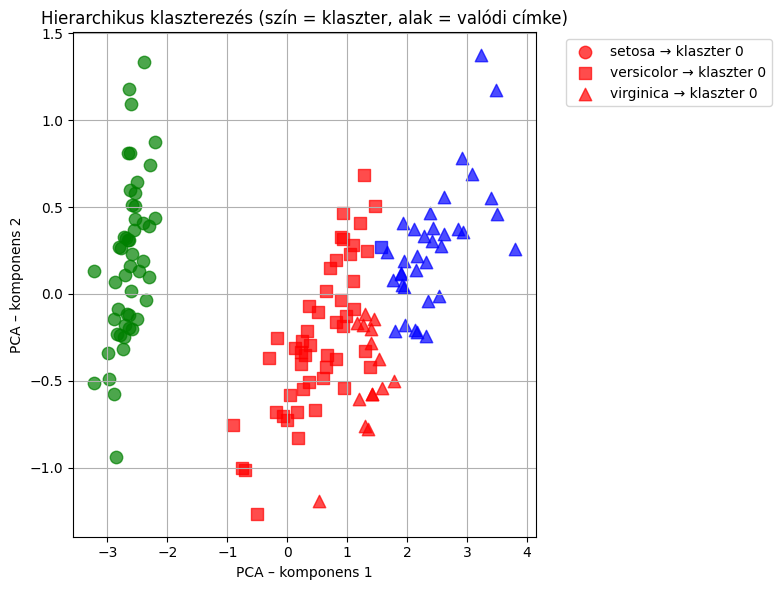

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

# 1. Adatok betöltése
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# 2. Agglomeratív klaszterezés
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = model.fit_predict(X)

# 3. PCA vizualizációhoz
X_pca = PCA(n_components=2).fit_transform(X)

# 4. Markerek a valódi címkékhez
markers = ['o', 's', '^']  # setosa, versicolor, virginica
colors = ['red', 'green', 'blue']  # klaszterek színei

# 5. Ábra: marker = valódi címke, szín = klaszter
plt.figure(figsize=(8, 6))
for i in range(3):  # 3 valódi osztály
    for j in range(3):  # 3 klaszter
        mask = (y == i) & (labels == j)
        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            marker=markers[i],
            color=colors[j],
            s=80,
            label=f"{target_names[i]} → klaszter {j}" if j == 0 else "",
            alpha=0.7
        )

# Klaszterközéppontok nem állnak rendelkezésre explicit módon
plt.title("Hierarchikus klaszterezés (szín = klaszter, alak = valódi címke)")
plt.xlabel("PCA – komponens 1")
plt.ylabel("PCA – komponens 2")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Klaszterezés kiértékelése

**Confusion matrix**:
- Bár a klaszterezés nem tanulta a címkéket, a mátrixból láthatjuk, hogy a klaszterek mennyire fedik le a valódi osztályokat.

**Silhouette score**:
- Azt méri, hogy az egyes pontok mennyire „közel” vannak a saját klaszterközéppontjukhoz és „távol” más klaszterektől.
- Értéke 0.0 körül: klaszterek összemosódnak.
- Értéke ~0.5 vagy magasabb: klaszterek jól elkülönülnek.

### Confusion Matrix

Confusion Matrix: Összehasonlítja a klasztereket a valódi címkékkel
(Bár a klaszterek nem tanulták a címkéket, mégis összevethetjük őket.)

In [54]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# Confusion matrix létrehozása
cm = confusion_matrix(y, labels)

# Pandas DataFrame formázásban (jobb áttekinthetőséghez)
df_cm = pd.DataFrame(
    cm,
    index=[f"Valódi: {name}" for name in target_names],
    columns=[f"Klaszter {i}" for i in range(3)]
)

print("Confusion matrix (valódi címkék vs klaszterek):")
display(df_cm)


Confusion matrix (valódi címkék vs klaszterek):


,Klaszter 0,Klaszter 1,Klaszter 2
Valódi: setosa,0,50,0
Valódi: versicolor,49,0,1
Valódi: virginica,15,0,35


### Silhouette Score

Silhouette Score: Megmutatja, mennyire jól elkülönülnek a klaszterek

Értéke: [-1, 1] között

~0 → határeset, rosszul elkülönülő klaszterek

0.5 → jól elkülönülő, kompakt klaszterek

In [57]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, labels)
print(f"Silhouette score: {score:.3f}")


Silhouette score: 0.554


### DBScan

 DBSCAN (Density-Based Spatial Clustering of Applications with Noise) algoritmust, ami egy sűrűség-alapú klaszterezési módszer – és nem igényli, hogy megadjuk a klaszterek számát előre!

DBSCAN
- Kisűrűségű pontokat zajnak (outliernek) tekint (címke: -1),
- Csak a sűrűen elhelyezkedő adatokat csoportosít klaszterekbe,

Nem igényli n_clusters paramétert, hanem:
- eps: mekkora sugarú körben nézzük a szomszédokat,
- min_samples: legalább hány pont legyen az adott körben -> hogy klaszterpont legyen.

In [61]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Betöltés és skálázás (DBSCAN érzékeny a skálára!)
X_scaled = StandardScaler().fit_transform(X)

# 2. DBSCAN klaszterezés
db = DBSCAN(eps=0.6, min_samples=5)
labels = db.fit_predict(X_scaled)

# 3. Hány klasztert talált? (-1 = outlier)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"DBSCAN klaszterek száma: {n_clusters}")
print(f"Zaj (outlier) pontok száma: {(labels == -1).sum()}")


DBSCAN klaszterek száma: 2
Zaj (outlier) pontok száma: 26


In [63]:
# 4. PCA a vizualizációhoz
X_pca = PCA(n_components=2).fit_transform(X_scaled)

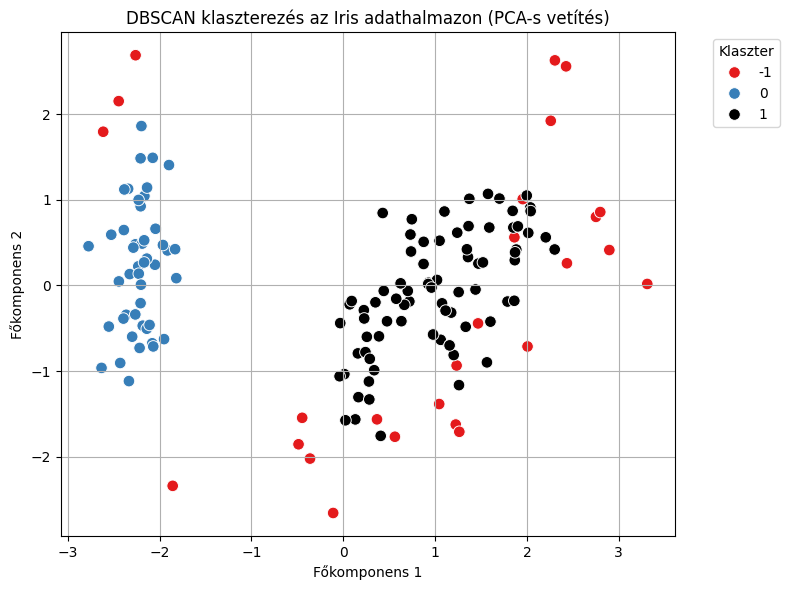

In [67]:
# 5. Ábra (szín: klaszter, -1 fekete pont = outlier)
plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set1", n_colors=n_clusters)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                hue=labels, palette=palette + [(0,0,0)],
                style=(y if isinstance(y, list) else None),
                s=70, legend="full")

plt.title("DBSCAN klaszterezés az Iris adathalmazon (PCA-s vetítés)")
plt.xlabel("Főkomponens 1")
plt.ylabel("Főkomponens 2")
plt.legend(title="Klaszter", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


Eredmény értelmezése:
- A -1-es címkéjű pontok = zaj (nem illeszkednek egy klaszterbe sem).

A DBSCAN jól kezeli az egyenetlen sűrűségű klasztereket, de az eps és min_samples értékére nagyon érzékeny.

### Klaszterezési módszerek összehasonlítása

Az alábbi táblázat három gyakran használt klaszterezési eljárást hasonlít össze — a **KMeans**, a **Hierarchikus**, és a **DBSCAN** módszereket — főbb jellemzőik alapján.

| Tulajdonság | **KMeans** | **Hierarchikus klaszterezés** | **DBSCAN** |
|--------------|-------------|-------------------------------|-------------|
| **Klaszterszám (K) megadása** | Igen (előre meg kell adni) | Nem szükséges – dendrogram alapján választható | Nem szükséges |
| **Alapelv** | Távolság-alapú, iteratív középpontfrissítés | Összeolvadás (agglomeratív) vagy szétválás (divizív) | Sűrűség-alapú csoportosítás |
| **Zaj / outlier kezelés** | Rossz – minden pontot be kell sorolni | Közepes – nincs külön zajfogalom | Jó – a ritka pontok zajként (-1) jelölődnek |
| **Klaszterek formája** | Gömbszerű | Tetszőleges | Tetszőleges |
| **Érzékenység a skálára** | Magas – előzetes skálázás ajánlott | Közepes | Nagyon magas (eps és min_samples érzékenyek) |
| **Előnyök** | Egyszerű, gyors, jól működik sok adattal | Látványos dendrogram, nem igényel K-t | Kezeli a zajt és nem konvex klasztereket is |
| **Hátrányok** | Nem jól kezeli a különböző sűrűségű vagy nem gömb alakú csoportokat | Nagy adathalmazon lassú | Paraméterválasztás nehéz, érzékeny |
| **Tipikus alkalmazás** | Ügyfélszegmentálás, képfeldolgozás | Biológiai minták, hierarchiák feltárása | Földrajzi, szenzoros, vagy anomáliás adatok |

**Összefoglalás:**  
- A *KMeans* gyors és intuitív, ha tudjuk, hány klaszter várható.  
- A *Hierarchikus* módszer jól szemlélteti a csoportosulások szerkezetét.  
- A *DBSCAN* különösen hasznos, ha az adatokban zaj vagy eltérő sűrűség van.


### K-Modes algoritmus

A **K-Modes** algoritmus a K-Means kategóriás adatokra adaptált változata.

Mivel a kategóriás változók esetében nem számolhatunk átlagot, a K-Modes a klaszterek középpontját módusszal (leggyakoribb érték) határozza meg.

**Alapelv:**
- Az elemek közötti hasonlóságot **kategóriák egyezése** alapján méri (pl. hány jellemző különbözik).
- A klaszterek középpontja (centroidja) az egyes jellemzők leggyakoribb értéke lesz.
- Minden elem ahhoz a klaszterhez tartozik, amelyikhez **legkevesebb eltérése** van.

**Tipikus felhasználás:**
- Ügyféltípusok szegmentálása kategóriás változók (pl. nem, régió, előfizetési csomag) alapján.
- Marketing, demográfiai vagy kérdőíves adatok elemzése.


In [101]:
#!pip install kmodes --quiet

In [113]:
# Példa: K-Modes algoritmus a Titanic adatokon
import pandas as pd
from kmodes.kmodes import KModes
import seaborn as sns

# Titanic adat betöltése
df = sns.load_dataset("titanic")


In [115]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [117]:
df = df[["sex", "class", "embarked", "alive"]].dropna()

In [119]:
# Kategóriás jellemzők kiválasztása
X = df[["sex", "class", "embarked"]]

# K-Modes modell (3 klaszter)
km = KModes(n_clusters=3, init="Huang", n_init=5, random_state=42)
clusters = km.fit_predict(X)

# Klaszterek hozzáadása az adatkerethez
df["cluster"] = clusters

# Klaszterek összefoglalása
print(df.groupby("cluster")[["sex", "class", "embarked"]].agg(lambda x: x.value_counts().index[0]))


            sex   class embarked
cluster                         
0          male   Third        S
1          male  Second        S
2        female   Third        S


**Mit látunk?**

- A K-Modes az utasokat kategóriás jellemzők alapján csoportosította (nem, osztály, indulási hely).
- Minden klaszterben megjelenik a legjellemzőbb kombináció (pl. nő–első osztály–Cherbourg).
- A K-Modes tehát numerikus számítás nélkül, diszkrét kategóriák alapján fedez fel mintázatokat.


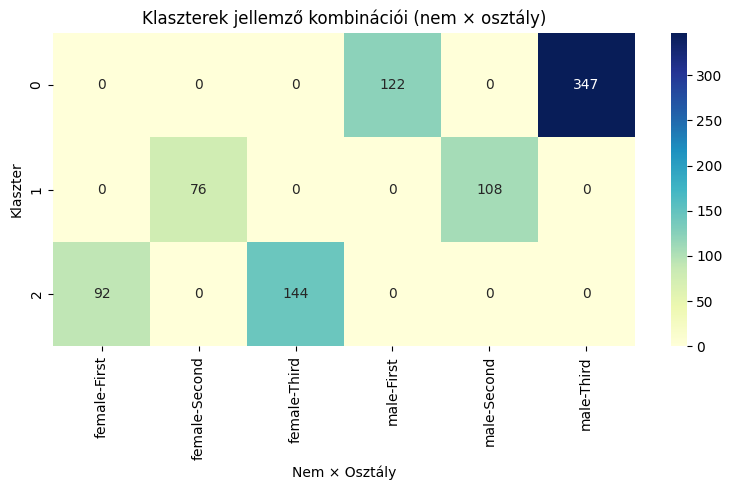

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot heatmap (kombinált nézet)
pivot = pd.crosstab(df["cluster"], [df["sex"], df["class"]])
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Klaszterek jellemző kombinációi (nem × osztály)")
plt.xlabel("Nem × Osztály")
plt.ylabel("Klaszter")
plt.tight_layout()
plt.show()


### KMeans klaszterezés kategóriás adatokon – embedding segítségével

A Word2Vec és BERT modellekhez hasonló elgondolás:  
a szavakat (kategóriákat) numerikus vektorokká alakítjuk, majd ezeket a vektorokat használjuk klaszterezésre.

Például a Titanic adathalmazban a `sex`, `class`, `who`, `embarked`, `alive` mezők kategóriásak — de embedding-gé alakíthatók, és így **KMeans**-szel is feldolgozhatók.


In [124]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Adatok előkészítése
df = sns.load_dataset("titanic").loc[:, ["sex", "class", "who", "embarked", "alive"]].dropna()

# 2️Kategóriás → numerikus átalakítás (embedding-szerű OneHot kódolás)
encoder = OneHotEncoder(sparse_output=False)
X_encoded = encoder.fit_transform(df)

# KMeans klaszterezés
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_encoded)

df["cluster"] = labels

# 4️⃣ Klaszterek gyors összegzése
summary = df.groupby("cluster").agg(lambda x: x.value_counts().index[0])
display(summary)


,sex,class,who,embarked,alive
cluster,,,,,
0,male,Third,man,S,no
1,female,First,woman,S,yes
2,female,Third,woman,S,no


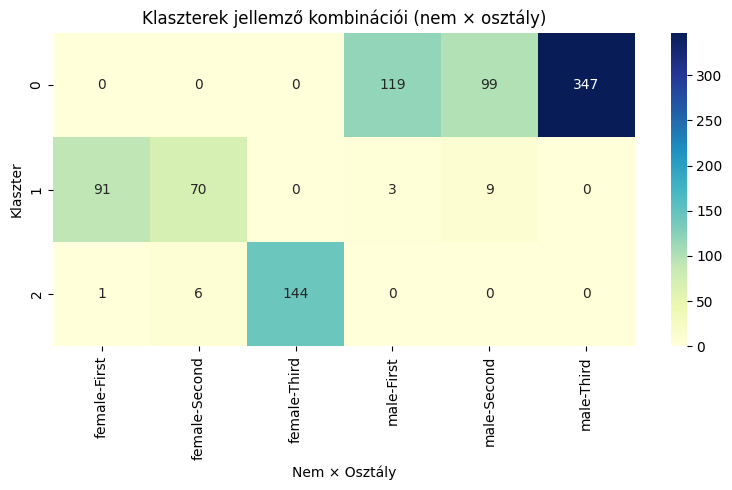

In [126]:
# Pivot heatmap (kombinált nézet)
pivot = pd.crosstab(df["cluster"], [df["sex"], df["class"]])
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Klaszterek jellemző kombinációi (nem × osztály)")
plt.xlabel("Nem × Osztály")
plt.ylabel("Klaszter")
plt.tight_layout()
plt.show()


### KMeans klaszterezés BERT-embeddingekkel

A BERT-modellek képesek szöveges bekezdéseket, mondatokat vagy akár kategória-kombinációkat  
**numerikus vektorokká (embeddingekké)** alakítani.  

Ezek a vektorok már a jelentésbeli hasonlóságot tükrözik, így a **KMeans** képes felismerni,  
hogy például „female, First class, alive” hasonló jelentésű, mint „woman, rich, survived”.



In [134]:
# Telepítés (ha szükséges)
#!pip install -q sentence-transformers


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/28 [00:00<?, ?it/s]

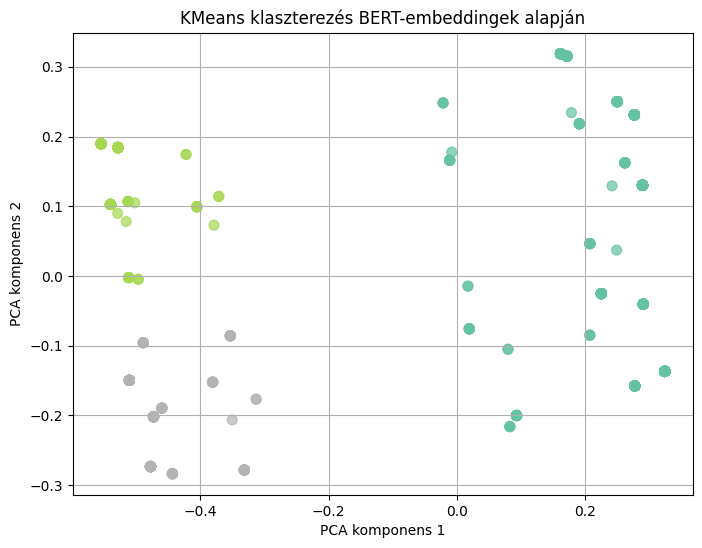

In [136]:

import pandas as pd
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1️⃣ Adatok betöltése
df = sns.load_dataset("titanic").loc[:, ["sex", "class", "who", "embarked", "alive"]].dropna()

# 2️⃣ Minden sort "szöveggé" alakítunk
df["text"] = df.apply(lambda r: f"{r['sex']} {r['class']} class {r['who']} embarked {r['embarked']} alive {r['alive']}", axis=1)

# 3️⃣ BERT-alapú embedding generálása
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["text"].tolist(), show_progress_bar=True)

# 4️⃣ KMeans klaszterezés
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(embeddings)
df["cluster"] = labels

# 5️⃣ Vizualizáció PCA-val
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
plt.scatter(coords[:,0], coords[:,1], c=labels, cmap="Set2", s=50, alpha=0.7)
plt.title("KMeans klaszterezés BERT-embeddingek alapján")
plt.xlabel("PCA komponens 1")
plt.ylabel("PCA komponens 2")
plt.grid(True)
plt.show()


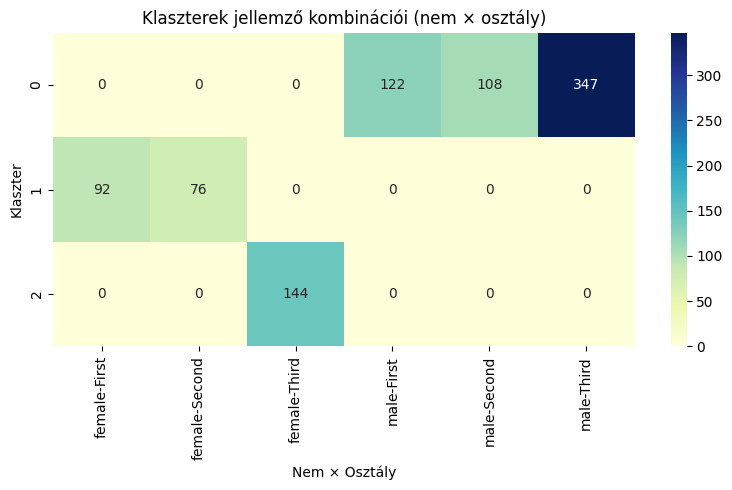

In [138]:
# Pivot heatmap (kombinált nézet)
pivot = pd.crosstab(df["cluster"], [df["sex"], df["class"]])
plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Klaszterek jellemző kombinációi (nem × osztály)")
plt.xlabel("Nem × Osztály")
plt.ylabel("Klaszter")
plt.tight_layout()
plt.show()

### Magyarázható mesterséges intelligencia (XAI – Explainable AI)

A magyarázható mesterséges intelligencia (XAI – Explainable AI) témakörben azt vizsgáljuk:
-  Miért hozott egy modell ilyen döntést?
- És melyik jellemző befolyásolta leginkább az eredményt?

Az egyik legjobb gyakorlati kombináció erre:

Példa:
- Túltanított Decision Tree +
- LIME vagy SHAP -> látjuk, miért döntött így a modell egy adott mintára

Cél:
- Túlkomplex modell (Decision Tree) készítése, hogy legyen mit megmagyarázni.
- Egy egyes adatpont predikciójának magyarázata (LIME / SHAP)

 ### Túltanított döntési fa modell

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

# Iris adat betöltése
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Osztott tanító és teszthalmaz
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Túlméretezett döntési fa – overfitting célból
model = DecisionTreeClassifier(max_depth=None, random_state=42)
model.fit(X_train, y_train)

# Egy predikció megtekintése
sample = X_test.iloc[[0]]
pred = model.predict(sample)
print(f"Előrejelzett osztály: {iris.target_names[pred[0]]}")


Előrejelzett osztály: versicolor


LIME magyarázat

In [75]:
#!pip install lime --quiet

In [77]:
from lime.lime_tabular import LimeTabularExplainer

# LIME inicializálás
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=iris.target_names,
    mode='classification'
)

# Magyarázat egy adott minta esetén
exp = explainer.explain_instance(sample.values[0], model.predict_proba, num_features=4)
exp.show_in_notebook()


### Mit látunk pontosan?


Predikciós valószínűségek (bal oldal):
A modell szerint a bemeneti virág:
- 0% eséllyel "setosa"
- 100% eséllyel "versicolor"
- 0% eséllyel "virginica"
A modell tehát teljes bizonyossággal (1.00) azt jósolja, hogy a virág versicolor.



### Döntési magyarázatok (középen):

Ez egy magyarázhatósági eszköz vizualizációja (pl. SHAP vagy LIME), ami azt mutatja, mely jellemzők járultak hozzá a versicolor döntéshez:

A következő jellemzők növelték a versicolor osztály valószínűségét (narancssárgával):
- "Petal length (cm) = 4.70" > 4.30 → nagy hatással (0.43)
- "Petal width (cm) = 1.20" > 0.30 → kisebb, de szintén pozitív hatással (0.16)

A másik oldalon (világoskék) nagyon kis mértékben megjelenik:
- "Sepal length" és "Sepal width" – de ezek csak elhanyagolható mértékben tolják az osztályozást a "nem versicolor" irányba (pl. 0.01, 0.03).



Ez megmutatja:
- Melyik jellemzők járultak hozzá a predikcióhoz,
- Milyen irányba (pozitív/negatív),
- Milyen mértékben.

### SHAP magyarázat

In [82]:
#!pip install shap --quiet

In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = DecisionTreeClassifier(max_depth=None, random_state=42)
model.fit(X_train, y_train)

sample = X_test.iloc[[0]]
pred = model.predict(sample)
print(f"Előrejelzett osztály: {iris.target_names[pred[0]]}")


Előrejelzett osztály: versicolor


In [86]:
import shap

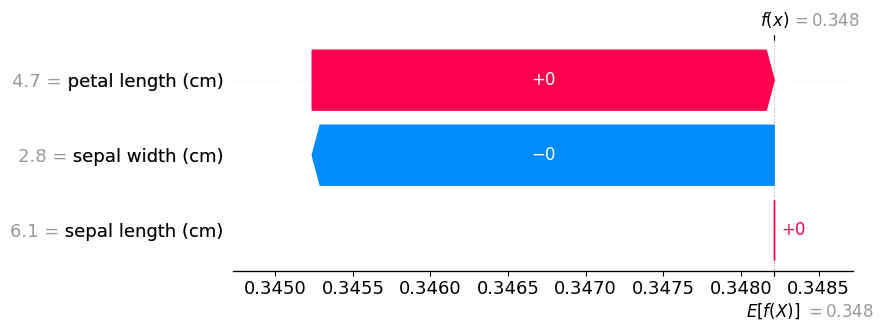

In [88]:
# SHAP értékek létrehozása "raw" model_output-tal
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Predikció osztály index (pl. 0. minta)
pred_class = model.predict(sample)[0]

# Waterfall plot az első mintára, predikált osztály SHAP értékeivel
shap.plots.waterfall(shap.Explanation(
    values=shap_values.values[0, pred_class],
    base_values=shap_values.base_values[0, pred_class],
    data=shap_values.data[0],
    feature_names=shap_values.feature_names
))



Mit jelent ez az ábra?


A tengely értelmezése:
- E[f(X)] = 0.348 → az átlagos (baseline) valószínűsége az adott osztálynak az összes tanítóadat alapján.
- f(x) = 0.348 → az adott virágra jósolt valószínűség az adott osztályra.

Mivel nincs jelentős elmozdulás → az adott jellemzők nem mozdították el a döntést szignifikánsan.



Mit mutatnak a sávok?
-  Kék sáv (negatív SHAP érték): az adott jellemző visszahúzta a predikciót az osztály irányából (pl. sepal width (cm) csökkentette a valószínűséget).
-  Piros sáv (pozitív SHAP érték): az adott jellemző megerősítette a predikciót az osztály irányába (pl. petal length (cm) kicsit növelte).

A számok nagyon kicsik, tehát a modell nem túl „magabiztos”.